<a href="https://colab.research.google.com/github/Pidekk/Pulpit_MPC-MLF/blob/main/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
#from keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 1.1 Generating dataset

In [ ]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [ ]:
data_size = 100000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [ ]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [ ]:
no_training_epochs = 5

### 1.3 Data examination

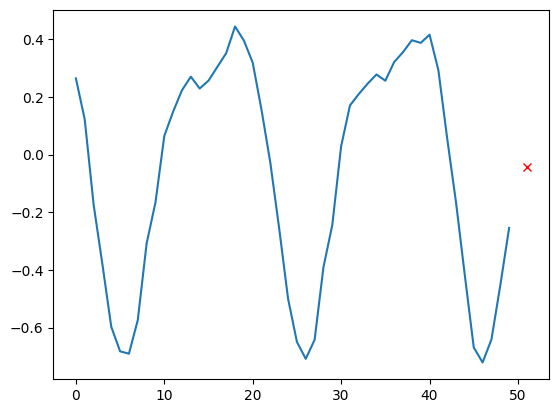

In [ ]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [ ]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [ ]:
model_linear.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2140 - mean_squared_error: 0.2140 - val_loss: 0.0645 - val_mean_squared_error: 0.0645
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0420 - mean_squared_error: 0.0420 - val_loss: 0.0283 - val_mean_squared_error: 0.0283
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0223 - mean_squared_error: 0.0223 - val_loss: 0.0192 - val_mean_squared_error: 0.0192
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0162 - val_mean_squared_error: 0.0162
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0145 - val_mean_squared_error: 0.0145


In [ ]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

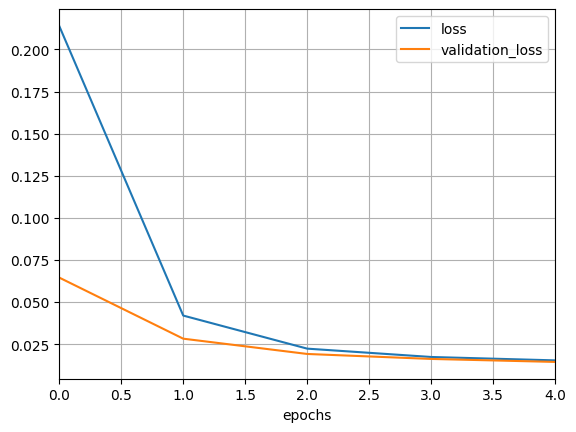

In [ ]:
plot_function(history_linear)

In [ ]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.014547307975590229
Test MSE:  0.014547307975590229


### 1.5 Simple RNN Model

In [ ]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [ ]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3045 - mean_squared_error: 0.3045 - val_loss: 0.2810 - val_mean_squared_error: 0.2810
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2606 - mean_squared_error: 0.2606 - val_loss: 0.2389 - val_mean_squared_error: 0.2389
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2216 - mean_squared_error: 0.2216 - val_loss: 0.2033 - val_mean_squared_error: 0.2033
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1876 - mean_squared_error: 0.1876 - val_loss: 0.1716 - val_mean_squared_error: 0.1716
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1600 - mean_squared_error: 0.1600 - val_loss: 0.1449 - val_mean_squared_error: 0.1449


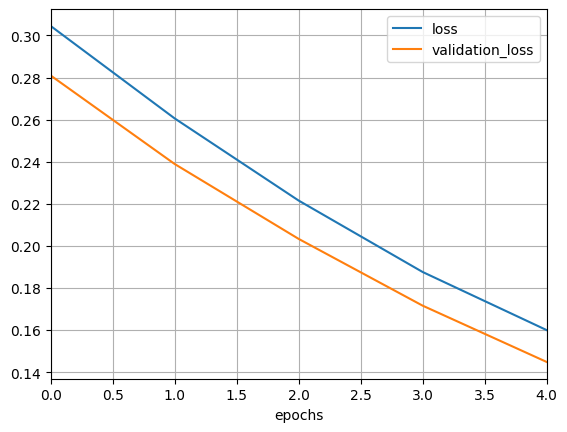

In [ ]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [ ]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [ ]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [ ]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0292 - mean_squared_error: 0.0292 - val_loss: 0.0066 - val_mean_squared_error: 0.0066
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0061 - mean_squared_error: 0.0061 - val_loss: 0.0048 - val_mean_squared_error: 0.0048
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0047 - val_mean_squared_error: 0.0047
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0036 - val_mean_squared_error: 0.0036
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0038 - val_mean_squared_error: 0.0038


In [ ]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.00382913532666862
Test MSE:  0.00382913532666862


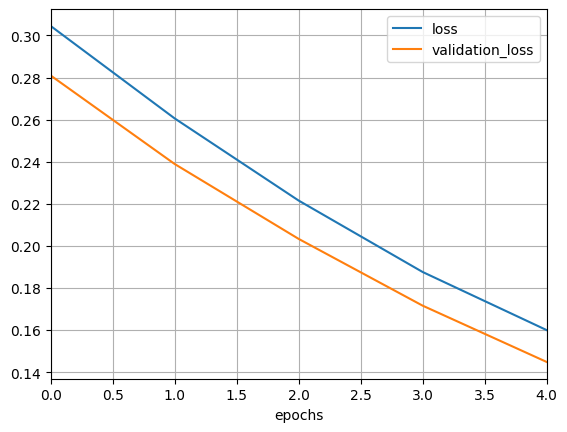

In [ ]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

### 2.1 - Load dataset

In [ ]:
size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=size)

### 2.2 - Dataset examination

In [ ]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [ ]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [ ]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what

In [ ]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [ ]:
embed_size = 128
vocabulary_size = 10000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [ ]:
optimizer = Adam(learning_rate = 0.0001)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4979 - loss: 0.6985 - val_accuracy: 0.5062 - val_loss: 0.7015
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5609 - loss: 0.6796 - val_accuracy: 0.5094 - val_loss: 0.7036
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.7509 - loss: 0.5057 - val_accuracy: 0.7206 - val_loss: 0.6070
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9227 - loss: 0.2108 - val_accuracy: 0.7172 - val_loss: 0.6532
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9718 - loss: 0.0956 - val_accuracy: 0.7306 - val_loss: 0.7337


In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.7741986513137817
Test accuracy:  72.44799733161926 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

LTSM

In [ ]:

embed_size = 128
vocabulary_size = 5000
max_length = 150

model_lstm = Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    LSTM(128, return_sequences=True),
    LSTM(128),
    Dense(1, activation='sigmoid')
])


optimizer = Adam(learning_rate=0.005)
model_lstm.compile(loss="binary_crossentropy",
                   optimizer=optimizer,
                   metrics=["accuracy"])


history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=5,
                              batch_size=16,
                              validation_split=0.2)

score = model_lstm.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.5188 - loss: 0.6941 - val_accuracy: 0.4938 - val_loss: 0.6980
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6170 - loss: 0.6399 - val_accuracy: 0.7208 - val_loss: 0.5487
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7862 - loss: 0.4655 - val_accuracy: 0.8036 - val_loss: 0.4432
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8387 - loss: 0.3779 - val_accuracy: 0.8104 - val_loss: 0.4416
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8615 - loss: 0.3332 - val_accuracy: 0.8298 - val_loss: 0.3980
Test loss: 0.41018563508987427
Test accuracy:  81.51999711990356 %


GRU

In [ ]:

embed_size = 128
vocabulary_size = 5000
max_length = 150

model_gru = Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    GRU(128, return_sequences=True,dropout = 0.1),
    GRU(128),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.005)
model_gru.compile(loss="binary_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])

history_gru = model_gru.fit(X_train, y_train,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.2)

score = model_gru.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5490 - loss: 0.6771 - val_accuracy: 0.6730 - val_loss: 0.6177
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8242 - loss: 0.3914 - val_accuracy: 0.8408 - val_loss: 0.3556
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8967 - loss: 0.2549 - val_accuracy: 0.8510 - val_loss: 0.3553
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9362 - loss: 0.1712 - val_accuracy: 0.8412 - val_loss: 0.4068
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9604 - loss: 0.1096 - val_accuracy: 0.8350 - val_loss: 0.5280
Test loss: 0.5386061072349548
Test accuracy:  82.95199871063232 %


In [ ]:
embed_size = 256
vocabulary_size = 15000
max_length = 150

model_gru2 = Sequential([
    Embedding(vocabulary_size, embed_size, input_shape=[None]),
    GRU(128, return_sequences=True,dropout = 0.1),
    GRU(128,return_sequences=True,dropout = 0.01),
    GRU(128,return_sequences=True),
    GRU(128),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model_gru2.compile(loss="binary_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])

history_gru = model_gru2.fit(X_train, y_train,
                            epochs=6,
                            batch_size=512,
                            validation_split=0.05)

score = model_gru2.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Epoch 1/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.5327 - loss: 0.6891 - val_accuracy: 0.5792 - val_loss: 0.6844
Epoch 2/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.6931 - loss: 0.5984 - val_accuracy: 0.7672 - val_loss: 0.5344
Epoch 3/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8056 - loss: 0.4591 - val_accuracy: 0.8248 - val_loss: 0.4130
Epoch 4/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8903 - loss: 0.2838 - val_accuracy: 0.8320 - val_loss: 0.3934
Epoch 5/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.9224 - loss: 0.2157 - val_accuracy: 0.8488 - val_loss: 0.3867
Epoch 6/6
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9454 - loss: 0.1643 - val_accuracy: 0.8568 - val_loss: 0.4297
Test loss: 0.458673894405365
Test accuracy:  83.82400274276733 %
